# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Carga de las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

## Carga de los datos

In [2]:
data = pd.read_csv('/datasets/taxi.csv')

## Preparación

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [4]:
data['datetime'] = data['datetime'].astype('datetime64')
data = data.set_index('datetime')
data = data.resample('1H').sum()

In [5]:
print(data.isna().sum())

num_orders    0
dtype: int64


## Análisis

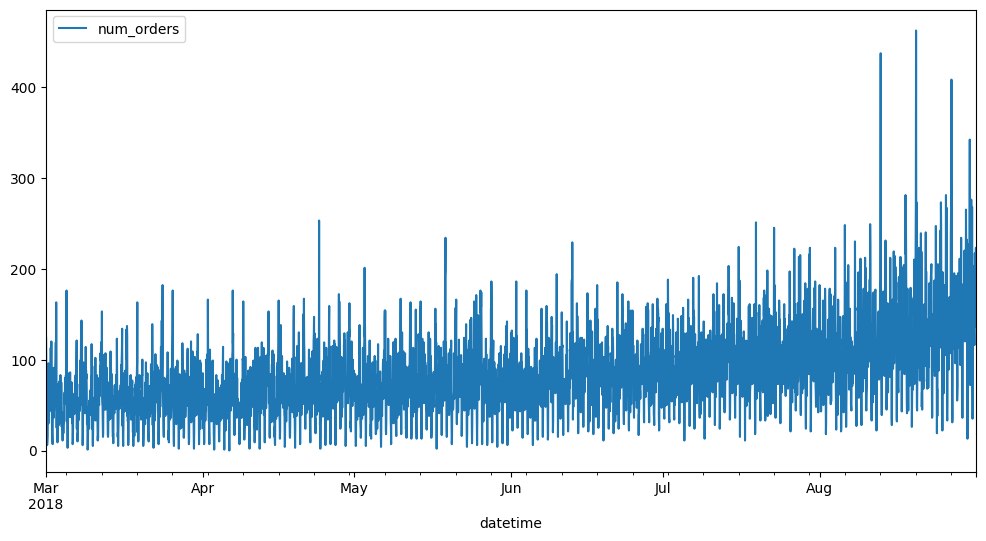

In [6]:
data.plot(figsize=(12,6))
plt.show()

## Formación

In [7]:
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month

In [8]:
for lag in range(1, 25):
    data[f'lag_{lag}'] = data['num_orders'].shift(lag)

In [9]:
data['rolling_mean'] = data['num_orders'].shift().rolling(24).mean()
data = data.dropna()

In [10]:
target = data['num_orders']
features = data.drop('num_orders', axis=1)

In [11]:
split_index = int(len(data) * 0.9)

X_train = features.iloc[:split_index]
X_test = features.iloc[split_index:]

y_train = target.iloc[:split_index]
y_test = target.iloc[split_index:]

<b>Modelo 1 'Regresion Lineal'

In [12]:
start = time.time()

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 45.71261965822819


<b> Modelo 2 'Random Forest'

In [13]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=12345,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 43.65322253618166


<B> Modelo 3 'LightGBM'

In [14]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=12345,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test, pred_lgb))

print("LightGBM RMSE:", rmse_lgb)

LightGBM RMSE: 40.514744485810425


## Prueba

<b> Comparación

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LightGBM'],
    'RMSE': [rmse_lr, rmse_rf, rmse_lgb]
})

results

,Model,RMSE
0,Linear Regression,45.712620
1,Random Forest,43.653223
2,LightGBM,40.514744
